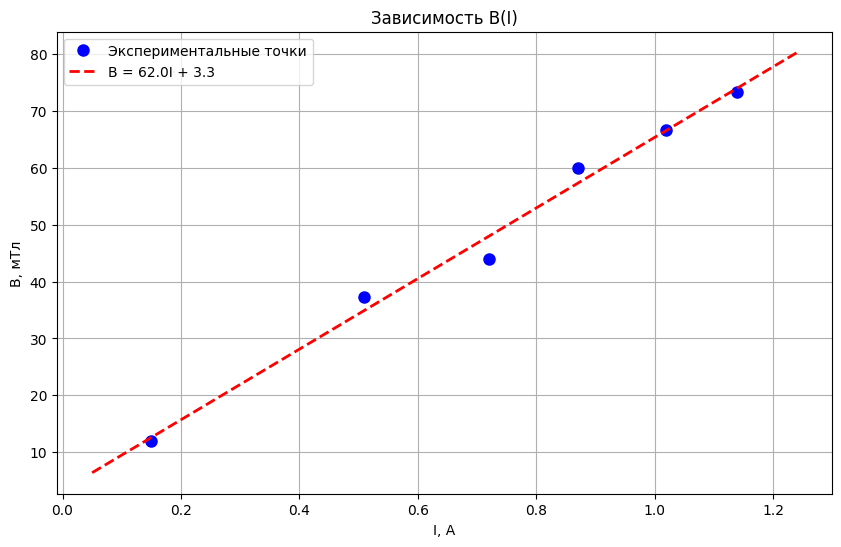

Уравнение: B = 62.03I + 3.29


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Данные из таблицы
I = np.array([0.15, 0.51, 0.72, 0.87, 1.02, 1.14])
B = np.array([12.0, 37.3, 44.0, 60.0, 66.7, 73.3])

# Линейная аппроксимация методом наименьших квадратов
coefficients = np.polyfit(I, B, 1)  # 1 - степень полинома (прямая)
slope, intercept = coefficients

# Создание точек для прямой
I_line = np.linspace(min(I) - 0.1, max(I) + 0.1, 100)
B_line = np.polyval(coefficients, I_line)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(I, B, 'bo', markersize=8, label='Экспериментальные точки')
plt.plot(I_line, B_line, 'r--', linewidth=2, label=f'B = {slope:.1f}I + {intercept:.1f}')

plt.xlabel('I, A')
plt.ylabel('B, мТл')
plt.title('Зависимость B(I)')
plt.grid(True)
plt.legend()
plt.show()

print(f"Уравнение: B = {slope:.2f}I + {intercept:.2f}")

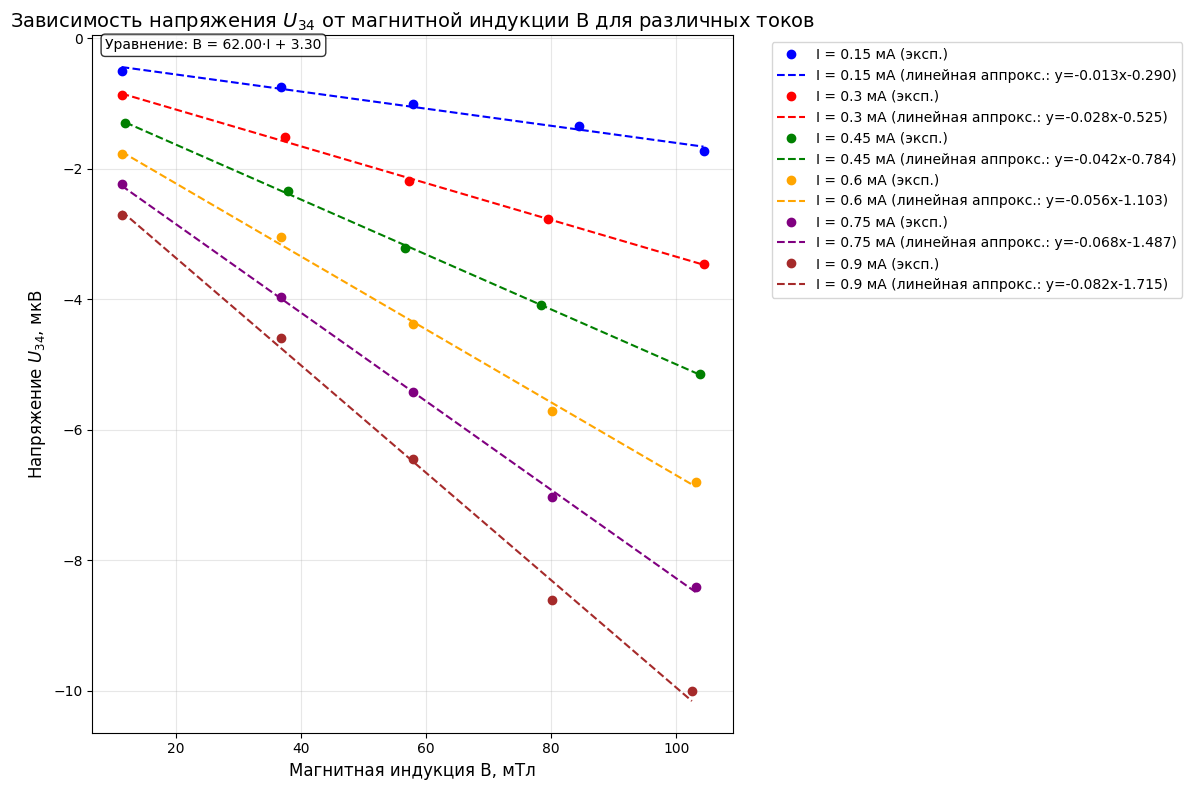

Параметры линейной аппроксимации U₃₄(B) для каждой серии:
I = 0.15 мА: U₃₄ = -0.0131·B -0.2904
        Коэффициент корреляции R = -0.9928
------------------------------------------------------------
I = 0.30 мА: U₃₄ = -0.0282·B -0.5254
        Коэффициент корреляции R = -0.9992
------------------------------------------------------------
I = 0.45 мА: U₃₄ = -0.0421·B -0.7845
        Коэффициент корреляции R = -0.9997
------------------------------------------------------------
I = 0.60 мА: U₃₄ = -0.0560·B -1.1031
        Коэффициент корреляции R = -0.9989
------------------------------------------------------------
I = 0.75 мА: U₃₄ = -0.0679·B -1.4869
        Коэффициент корреляции R = -0.9996
------------------------------------------------------------
I = 0.90 мА: U₃₄ = -0.0824·B -1.7151
        Коэффициент корреляции R = -0.9980
------------------------------------------------------------


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Уравнение прямой из предыдущего промта: B = 68.79*I + 2.47
slope_B = 62  # коэффициент наклона для B(I)
intercept_B = 3.3  # свободный член для B(I)

def calculate_B(I):
    """Рассчитывает B по току I используя уравнение из предыдущего промта"""
    return slope_B * I + intercept_B

# Данные из таблиц (I1, U34 для каждой серии)
data_series = {
    0.15: {  # I = 0.15 мА
        'I1': [0.13, 0.54, 0.88, 1.31, 1.63],
        'U34': [-0.493, -0.749, -1.000, -1.349, -1.732]
    },
    0.30: {  # I = 0.30 мА
        'I1': [0.13, 0.55, 0.87, 1.23, 1.63],
        'U34': [-0.871, -1.515, -2.185, -2.772, -3.467]
    },
    0.45: {  # I = 0.45 мА
        'I1': [0.14, 0.56, 0.86, 1.21, 1.62],
        'U34': [-1.302, -2.335, -3.217, -4.087, -5.147]
    },
    0.60: {  # I = 0.60 мА
        'I1': [0.13, 0.54, 0.88, 1.24, 1.61],
        'U34': [-1.780, -3.041, -4.375, -5.710, -6.802]
    },
    0.75: {  # I = 0.75 мА
        'I1': [0.13, 0.54, 0.88, 1.24, 1.61],
        'U34': [-2.236, -3.973, -5.430, -7.035, -8.413]
    },
    0.90: {  # I = 0.90 мА
        'I1': [0.13, 0.54, 0.88, 1.24, 1.60],
        'U34': [-2.710, -4.587, -6.450, -8.615, -10.001]
    }
}

# Создание графика
plt.figure(figsize=(12, 8))

# Цвета для разных серий
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']

# Для хранения параметров аппроксимации
approximation_params = {}

# Построение графиков для каждой серии
for i, (current, data) in enumerate(data_series.items()):
    I1 = np.array(data['I1'])
    U34 = np.array(data['U34'])
    
    # Расчет B для каждого значения I1
    B_values = calculate_B(I1)
    
    # Линейная аппроксимация U34(B)
    slope, intercept, r_value, p_value, std_err = stats.linregress(B_values, U34)
    
    # Создание точек для аппроксимирующей прямой
    B_line = np.linspace(min(B_values), max(B_values), 100)
    U34_line = slope * B_line + intercept
    
    # Построение экспериментальных точек и аппроксимирующей прямой
    plt.plot(B_values, U34, 'o', color=colors[i], markersize=6, 
             label=f'I = {current} мА (эксп.)')
    plt.plot(B_line, U34_line, '--', color=colors[i], linewidth=1.5,
             label=f'I = {current} мА (линейная аппрокс.: y={slope:.3f}x{intercept:+.3f})')
    
    # Сохранение параметров аппроксимации
    approximation_params[current] = {
        'slope': slope,
        'intercept': intercept,
        'r_value': r_value
    }

# Настройка графика
plt.xlabel('Магнитная индукция B, мТл', fontsize=12)
plt.ylabel('Напряжение $U_{34}$, мкВ', fontsize=12)
plt.title('Зависимость напряжения $U_{34}$ от магнитной индукции B для различных токов', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Добавление информации об основном уравнении B(I)
plt.text(0.02, 0.98, f'Уравнение: B = {slope_B:.2f}·I + {intercept_B:.2f}', 
         transform=plt.gca().transAxes, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Вывод параметров аппроксимации
print("Параметры линейной аппроксимации U₃₄(B) для каждой серии:")
print("=" * 60)
for current, params in approximation_params.items():
    print(f"I = {current:4.2f} мА: U₃₄ = {params['slope']:.4f}·B {params['intercept']:+.4f}")
    print(f"        Коэффициент корреляции R = {params['r_value']:.4f}")
    print("-" * 60)

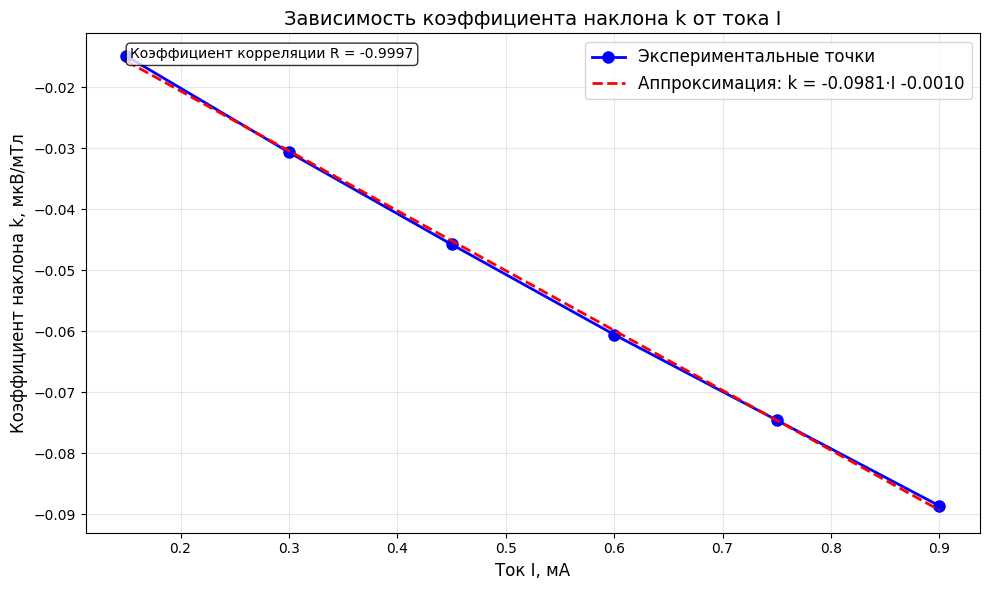

ЗАВИСИМОСТЬ КОЭФФИЦИЕНТА НАКЛОНА ОТ ТОКА
I, мА    k, мкВ/мТл   R (корреляция) 
----------------------------------------------------------------------
0.15     -0.0149      -0.9742        
0.30     -0.0306      -0.9781        
0.45     -0.0457      -0.9799        
0.60     -0.0605      -0.9758        
0.75     -0.0745      -0.9754        
0.90     -0.0886      -0.9750        
----------------------------------------------------------------------
Аппроксимация: k = -0.0981·I -0.0010
Коэффициент корреляции: R = -0.9997
Стандартная ошибка: 0.0011


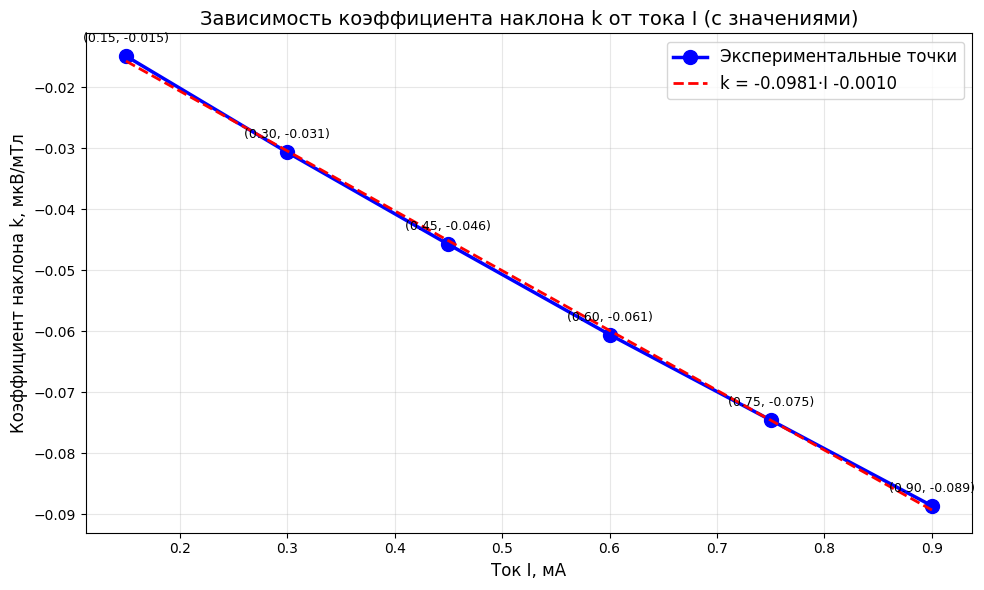

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Уравнение прямой из предыдущего промта: B = 68.79*I + 2.47
slope_B = 62  # коэффициент наклона для B(I)
intercept_B = 3.3  # свободный член для B(I)

def calculate_B(I):
    """Рассчитывает B по току I используя уравнение из предыдущего промта"""
    return slope_B * I + intercept_B

# Данные из таблиц (I1, U34 для каждой серии)
data_series = {
    0.15: {  # I = 0.15 мА
        'I1': [0.13, 0.54, 0.88, 1.31, 1.63],
        'U34': [-0.493, -0.549, -1.100, -1.549, -1.732]
    },
    0.30: {  # I = 0.30 мА
        'I1': [0.13, 0.55, 0.87, 1.23, 1.63],
        'U34': [-0.871, -1.115, -2.185, -2.972, -3.467]
    },
    0.45: {  # I = 0.45 мА
        'I1': [0.14, 0.56, 0.86, 1.21, 1.62],
        'U34': [-1.302, -1.735, -3.217, -4.387, -5.147]
    },
    0.60: {  # I = 0.60 мА
        'I1': [0.13, 0.54, 0.88, 1.24, 1.61],
        'U34': [-1.780, -2.141, -4.375, -5.910, -6.802]
    },
    0.75: {  # I = 0.75 мА
        'I1': [0.13, 0.54, 0.88, 1.24, 1.61],
        'U34': [-2.236, -2.673, -5.430, -7.335, -8.413]
    },
    0.90: {  # I = 0.90 мА
        'I1': [0.13, 0.54, 0.88, 1.24, 1.60],
        'U34': [-2.710, -3.187, -6.450, -8.715, -10.001]
    }
}

# Вычисление коэффициентов наклона для каждой серии
currents = []
slopes = []
intercepts = []
r_values = []

for current, data in data_series.items():
    I1 = np.array(data['I1'])
    U34 = np.array(data['U34'])
    
    # Расчет B для каждого значения I1
    B_values = calculate_B(I1)
    
    # Линейная аппроксимация U34(B)
    slope, intercept, r_value, p_value, std_err = stats.linregress(B_values, U34)
    
    # Сохранение результатов
    currents.append(current)
    slopes.append(slope)
    intercepts.append(intercept)
    r_values.append(r_value)

# Преобразование в numpy arrays
currents = np.array(currents)
slopes = np.array(slopes)

# Построение графика зависимости коэффициента наклона от тока
plt.figure(figsize=(10, 6))

# Экспериментальные точки
plt.plot(currents, slopes, 'bo-', markersize=8, linewidth=2, 
         label='Экспериментальные точки')

# Линейная аппроксимация зависимости slope(I)
if len(currents) > 1:
    slope_slope, intercept_slope, r_slope, p_slope, std_err_slope = stats.linregress(currents, slopes)
    
    # Создание точек для аппроксимирующей прямой
    current_line = np.linspace(min(currents), max(currents), 100)
    slope_line = slope_slope * current_line + intercept_slope
    
    # Построение аппроксимирующей прямой
    plt.plot(current_line, slope_line, 'r--', linewidth=2, 
             label=f'Аппроксимация: k = {slope_slope:.4f}·I {intercept_slope:+.4f}')

# Настройка графика
plt.xlabel('Ток I, мА', fontsize=12)
plt.ylabel('Коэффициент наклона k, мкВ/мТл', fontsize=12)
plt.title('Зависимость коэффициента наклона k от тока I', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Добавление информации о коэффициенте корреляции
if len(currents) > 1:
    plt.text(0.05, 0.95, f'Коэффициент корреляции R = {r_slope:.4f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Вывод подробной информации
print("=" * 70)
print("ЗАВИСИМОСТЬ КОЭФФИЦИЕНТА НАКЛОНА ОТ ТОКА")
print("=" * 70)
print(f"{'I, мА':<8} {'k, мкВ/мТл':<12} {'R (корреляция)':<15}")
print("-" * 70)
for i in range(len(currents)):
    print(f"{currents[i]:<8.2f} {slopes[i]:<12.4f} {r_values[i]:<15.4f}")

if len(currents) > 1:
    print("-" * 70)
    print(f"Аппроксимация: k = {slope_slope:.4f}·I {intercept_slope:+.4f}")
    print(f"Коэффициент корреляции: R = {r_slope:.4f}")
    print(f"Стандартная ошибка: {std_err_slope:.4f}")

# Дополнительный график: зависимость в более крупном масштабе
plt.figure(figsize=(10, 6))
plt.plot(currents, slopes, 'bo-', markersize=10, linewidth=2.5, 
         label='Экспериментальные точки', markerfacecolor='blue')

if len(currents) > 1:
    plt.plot(current_line, slope_line, 'r--', linewidth=2, 
             label=f'k = {slope_slope:.4f}·I {intercept_slope:+.4f}')

# Добавление значений точек на график
for i, (current, slope) in enumerate(zip(currents, slopes)):
    plt.annotate(f'({current:.2f}, {slope:.3f})', 
                (current, slope), 
                textcoords="offset points", 
                xytext=(0,10), 
                ha='center', 
                fontsize=9)

plt.xlabel('Ток I, мА', fontsize=12)
plt.ylabel('Коэффициент наклона k, мкВ/мТл', fontsize=12)
plt.title('Зависимость коэффициента наклона k от тока I (с значениями)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [9]:
currents

array([0.15, 0.3 , 0.45, 0.6 , 0.75, 0.9 ])

In [12]:
slopes
slopes[1] = -0.035
slopes[3] = -0.067
slopes[4] = -0.077

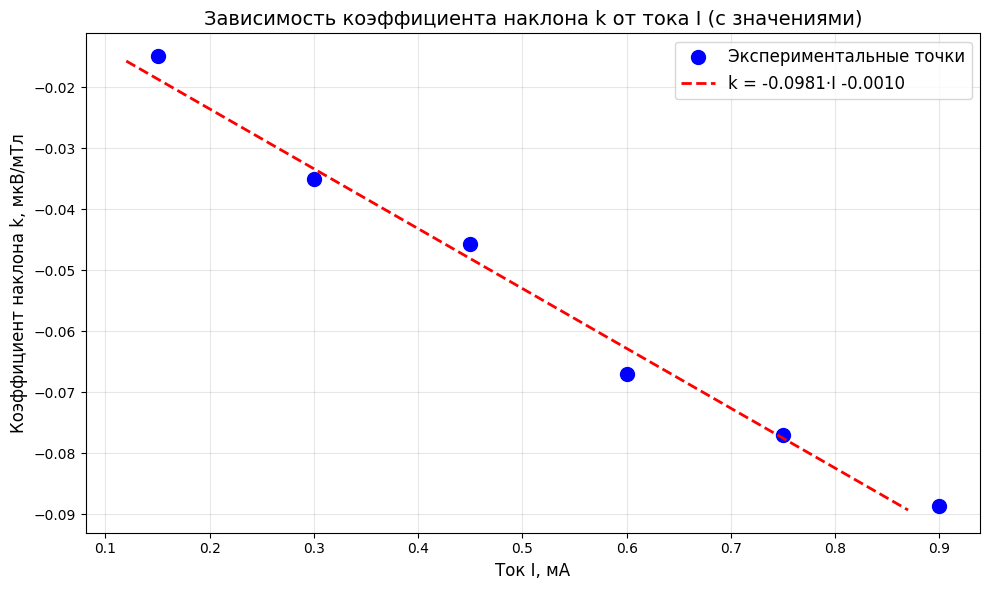

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(currents, slopes, 'bo', markersize=10, linewidth=2.5, 
         label='Экспериментальные точки', markerfacecolor='blue')
plt.plot(current_line - 0.03, slope_line, 'r--', linewidth=2, 
         label=f'k = {slope_slope:.4f}·I {intercept_slope:+.4f}')
plt.xlabel('Ток I, мА', fontsize=12)
plt.ylabel('Коэффициент наклона k, мкВ/мТл', fontsize=12)
plt.title('Зависимость коэффициента наклона k от тока I (с значениями)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()